

# US-JEPA Self-Supervised Pretraining CUBS Carotid Ultrasound

**Pure self-supervised pretraining pipeline.**


## 0. Install Dependencies

In [ ]:
!pip install -q torch torchvision einops matplotlib tqdm pillow
# Optional: TensorBoard logging
!pip install -q tensorboard
# ROI detection (connected components / morphology) for anatomy-aware masking
!pip install -q scipy

In [ ]:
!pip install -q scikit-image

## 1. Imports & Reproducibility

In [ ]:
import os
import glob
import copy
import json
import random
import math
import numpy as np

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

In [ ]:
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from skimage.morphology import convex_hull_image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD = True
except ImportError:
    TENSORBOARD = False
    print('TensorBoard not available — skipping TB logging.')

In [ ]:
from einops import rearrange
from scipy import ndimage as ndi
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [ ]:
# Configuration
CFG = {
    #Paths
    'data_dir'          : '/content/drive/MyDrive/IMAGES',
    'checkpoint_dir'    : './checkpoints',
    'log_dir'           : './runs/usjepa',

    #Image
    'img_size': 256,      # ViT standard; change to 256 if GPU memory allows
    'img_channels'      : 1,        # grayscale ultrasound

    #ViT encoder (context & target)
    'patch_size'        : 16,
    'embed_dim'         : 384,      # ViT-Small
    'encoder_depth'     : 8,
    'encoder_heads'     : 6,

    # Predictor
    'predictor_dim'     : 192,      # half of embed_dim
    'predictor_depth'   : 4,
    'predictor_heads'   : 4,

    #Masking
    'mask_ratio'        : 0.40,     # fraction of patches used as targets
    'n_target_blocks'   : 6,        # number of contiguous spatial blocks to mask
    'target_scale' :  (0.025, 0.05),  # scale range for each target block
    'target_aspect'     :  (0.5, 2.0),  # aspect ratio range for target blocks

    # EMA
    'ema_momentum_start': 0.996,
    'ema_momentum_end'  : 1.0,      # cosine schedule toward 1.0

    #Optimiser
    'optimizer'         : 'adamw',
    'lr'                : 1e-3,
    'min_lr'            : 1e-5,
    'weight_decay'      : 0.05,
    'warmup_epochs'     : 5,

    #Training
    'epochs'            : 100,
    'batch_size'        : 32,
    'val_fraction'      : 0.1,      # fraction of data held out for val loss tracking
    'num_workers'       : 2,
    'pin_memory'        : True,
    'mixed_precision'   : True,     # AMP — set False if you see instability

    # Checkpointing
    'save_every'        : 10,       # save checkpoint every N epochs
    'early_stop_patience': 20,      # stop if val loss does not improve for N epochs

    # Anti-collapse regularization (VICReg-style variance hinge)
    # JEPA/BYOL-style objectives can trivially minimise loss by collapsing all
    # embeddings to a near-constant vector. This term penalises the context
    # encoder whenever the per-dimension std of its (unmasked) output embeddings
    # drops below `variance_gamma`, actively discouraging that degenerate solution.
    'variance_loss_weight'   : 1.0,     # weight of the variance-hinge term added to the JEPA loss
    'variance_gamma'         : 1.0,     # target per-dimension std for context embeddings
    'variance_eps'           : 1e-4,    # numerical stability inside std()

    # Collapse-aware checkpointing / early stopping
    # A collapsed model trivially achieves the lowest possible raw JEPA loss, so
    # naive "save if val_loss improves" logic will happily checkpoint a collapsed
    # (useless) encoder as "best". These guards require training to run for a
    # minimum number of epochs, and the embeddings to show healthy variance,
    # before a checkpoint can be marked best or count toward early stopping.
    'min_epochs_before_stop' : 30,      # never treat an epoch as "best" or count patience before this epoch
    'collapse_std_thresh'    : 0.1,     # if mean per-dim std of context embeddings falls below this, treat the epoch as collapsed

    #Resume
    'resume_checkpoint' : None,     # set to path string to resume

    # Misc
    'seed'              : 42,
    'device'            : str(DEVICE),
    # Bounded random masking
    'min_block_distance' : 2,      # minimum gap between rectangles (patches)
    'max_overlap'        : 0.05,   # max allowed overlap ratio 5%
    'max_sampling_trials': 100,

    # ROI-aware masking (anatomy-only block sampling)
    'roi_intensity_thresh'    : 0.04,   # pixels below this (in [0,1]) are treated as black background
    'roi_open_kernel'         : 3,      # morphological opening kernel (px) — strips thin text strokes / speckle
    'roi_close_kernel'        : 5,      # morphological closing kernel (px) — fills small internal holes in the cone
    'roi_patch_valid_frac'    : 0.5,    # a patch counts as "valid" if ≥ this fraction of its pixels are ROI
    'roi_max_invalid_frac'    : 0.30,   # reject a sampled block if > this fraction of it lies outside the ROI
    'roi_min_valid_patches'   : 0.05,   # safety floor: if fewer than this fraction of patches are valid, ROI detector is
                                         # assumed to have failed and falls back to the full image (avoids empty masks)
    'restrict_context_to_roi': True,    # if True, visible/context patches are also restricted to ROI (not just targets)

    # Debugging
    'debug_check_shapes'     : False,   # set True to assert mask/shape invariants inside jepa_predictor_forward

    }

In [ ]:
os.makedirs(CFG['checkpoint_dir'], exist_ok=True)
os.makedirs(CFG['log_dir'],        exist_ok=True)

In [ ]:
# Save config snapshot
with open(os.path.join(CFG['checkpoint_dir'], 'config.json'), 'w') as f:
    json.dump(CFG, f, indent=2)

In [ ]:
print('Config ready.')
print(json.dumps(CFG, indent=2))

Config ready.
{
  "data_dir": "/content/drive/MyDrive/IMAGES",
  "checkpoint_dir": "./checkpoints",
  "log_dir": "./runs/usjepa",
  "img_size": 256,
  "img_channels": 1,
  "patch_size": 16,
  "embed_dim": 384,
  "encoder_depth": 8,
  "encoder_heads": 6,
  "predictor_dim": 192,
  "predictor_depth": 4,
  "predictor_heads": 4,
  "mask_ratio": 0.4,
  "n_target_blocks": 6,
  "target_scale": [
    0.025,
    0.05
  ],
  "target_aspect": [
    0.5,
    2.0
  ],
  "ema_momentum_start": 0.996,
  "ema_momentum_end": 1.0,
  "optimizer": "adamw",
  "lr": 0.001,
  "min_lr": 1e-05,
  "weight_decay": 0.05,
  "warmup_epochs": 5,
  "epochs": 100,
  "batch_size": 32,
  "val_fraction": 0.1,
  "num_workers": 2,
  "pin_memory": true,
  "mixed_precision": true,
  "save_every": 10,
  "early_stop_patience": 20,
  "variance_loss_weight": 1.0,
  "variance_gamma": 1.0,
  "variance_eps": 0.0001,
  "min_epochs_before_stop": 30,
  "collapse_std_thresh": 0.1,
  "resume_checkpoint": null,
  "seed": 42,
  "device": "c

## 3. Utilities

In [ ]:
# LR scheduling helpers
def cosine_lr_with_warmup(optimizer, epoch, cfg):
    """
    Linear warmup for `warmup_epochs`, then cosine decay to min_lr.
    Called once per epoch (after the step).
    """
    if epoch < cfg['warmup_epochs']:
        lr = cfg['lr'] * (epoch + 1) / cfg['warmup_epochs']
    else:
        progress = (epoch - cfg['warmup_epochs']) / max(1, cfg['epochs'] - cfg['warmup_epochs'])
        lr = cfg['min_lr'] + 0.5 * (cfg['lr'] - cfg['min_lr']) * (1 + math.cos(math.pi * progress))
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr

In [ ]:
def ema_momentum_schedule(epoch, cfg):
    """Cosine schedule for EMA momentum: start → end over all epochs."""
    m_start = cfg['ema_momentum_start']
    m_end   = cfg['ema_momentum_end']
    progress = epoch / max(1, cfg['epochs'])
    return m_end - (m_end - m_start) * (1 + math.cos(math.pi * progress)) / 2

Functional state helpers

In [ ]:
def move_model_dict_to_device(d, device):
    """Recursively move every nn.Module / nn.Parameter in a functional model dict to `device`."""
    if isinstance(d, dict):
        for k, v in d.items():
            d[k] = move_model_dict_to_device(v, device)
        return d
    elif isinstance(d, list):
        return [move_model_dict_to_device(v, device) for v in d]
    elif isinstance(d, nn.Module):
        return d.to(device)
    elif isinstance(d, nn.Parameter):
        d.data = d.data.to(device)
        return d
    else:
        return d  # plain ints/floats/tuples — leave untouched

In [ ]:
def serialize_functional_state(d):
    """Recursively extract clean, serializable weight state from a functional model dict."""
    if isinstance(d, dict):
        return {k: serialize_functional_state(v) for k, v in d.items()}
    elif isinstance(d, list):
        return [serialize_functional_state(v) for v in d]
    elif isinstance(d, nn.Module):
        return d.state_dict()
    elif isinstance(d, nn.Parameter):
        return d.data.cpu()
    else:
        return d

In [ ]:
def load_functional_state(saved, target):
    """Recursively load a saved state tree (from serialize_functional_state) back into a live functional model dict."""
    if isinstance(target, dict):
        for k in target:
            load_functional_state(saved[k], target[k])
    elif isinstance(target, list):
        for s, t in zip(saved, target):
            load_functional_state(s, t)
    elif isinstance(target, nn.Module):
        target.load_state_dict(saved)
    elif isinstance(target, nn.Parameter):
        target.data.copy_(saved.to(target.device))
    # else: static metadata (ints/floats/tuples) — nothing to restore

In [ ]:
# Checkpointing
def save_checkpoint(state, path):
    torch.save(state, path)
    print(f'  Checkpoint saved → {path}')

In [ ]:
def load_checkpoint(path, model_state, optimizer=None, scaler=None):
    ckpt = torch.load(path, map_location=DEVICE)
    load_functional_state(ckpt['model'], model_state)
    if optimizer and 'optimizer' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer'])
    if scaler and 'scaler' in ckpt:
        scaler.load_state_dict(ckpt['scaler'])
    print(f'Resumed from epoch {ckpt["epoch"]} | best_val={ckpt["best_val"]:.6f}')
    return ckpt['epoch'], ckpt['best_val'], ckpt.get('history', {'train': [], 'val': []})

In [ ]:
# Encoder export helper (used after pretraining)
def save_encoder_weights(encoder_dict, path):
    """Save only the context encoder's functional weight tree."""
    torch.save(serialize_functional_state(encoder_dict), path)
    print(f'  Encoder weights saved → {path}')

In [ ]:
def load_pretrained_encoder(cfg, weights_path, device):
    """
    Convenience loader for downstream fine-tuning.

    Usage:
        encoder = load_pretrained_encoder(cfg, 'encoder_final.pth', device)
        tokens  = vit_encoder_forward(x, encoder)
    """
    encoder = init_vit_encoder(
        img_size    = cfg['img_size'],
        patch_size  = cfg['patch_size'],
        in_channels = cfg['img_channels'],
        embed_dim   = cfg['embed_dim'],
        depth       = cfg['encoder_depth'],
        n_heads     = cfg['encoder_heads'],
    )
    encoder = move_model_dict_to_device(encoder, device)
    load_functional_state(torch.load(weights_path, map_location=device), encoder)
    print(f'Pretrained encoder loaded from {weights_path}')
    return encoder

In [ ]:
print('Utilities defined.')

Utilities defined.


### 3.1 ROI Detection — Anatomy-Only Region for Mask Sampling

Ultrasound frames typically contain a large sector/rectangular **cone of real tissue**
surrounded by:
* a black background / margins
* bright scanner UI text and measurement markers (usually small, isolated blobs)

`compute_roi_patch_mask` finds the cone automatically, **per image**, with no manual
cropping and no assumption about left/right orientation or exact cone size:

1. Threshold non-black pixels → rough foreground.
2. Morphological **opening** → strips thin bright text strokes and speckle noise
   (text annotations are thin/isolated, so a small opening kernel erases them while
   leaving the much larger, thicker tissue cone intact).
3. Keep only the **largest connected component** → the cone is virtually always the
   single largest blob; leftover UI text fragments are smaller, separate components
   and get discarded here even if the opening step didn't fully remove them.
4. Morphological **closing** + hole-filling → patches speckle-induced black holes
   *inside* the cone so they aren't misclassified as background.
5. Downsample to the ViT patch grid → a patch counts as valid ROI if enough of its
   pixels fall inside the cleaned foreground mask.
6. Safety fallback → if the detector finds almost nothing (degenerate/blank image),
   it falls back to treating the whole image as valid, so training never breaks.

This never crops or resizes the image — it only produces a same-size binary mask
used later to constrain **where** mask blocks may be sampled.

In [ ]:
def compute_roi_patch_mask(img01_np, grid_size, patch_size,
                            intensity_thresh=0.04,
                            open_kernel=3,
                            close_kernel=5,
                            patch_valid_frac=0.5,
                            min_valid_patch_frac=0.05):
    """
    Detects the valid ultrasound content region and downsamples it to the ViT patch grid.

    Args:
        img01_np: 2-D numpy array, values in [0, 1], shape (H, W) with
                  H == W == grid_size * patch_size.
        grid_size: number of patches per side.
        patch_size: patch size in pixels.
        intensity_thresh: pixels <= this value are treated as black background.
        open_kernel: morphological opening kernel size (px) to strip thin text/speckle.
        close_kernel: morphological closing kernel size (px) to fill small internal holes.
        patch_valid_frac: fraction of a patch's pixels that must be foreground for the
                           patch to be marked valid.
        min_valid_patch_frac: safety floor — if fewer than this fraction of all patches
                               are valid, the detector is assumed to have failed and the
                               whole image is treated as valid (prevents empty masks).

    Returns:
        pixel_mask: bool array (H, W) — True where pixels belong to the ROI.
        patch_mask: bool array (grid_size * grid_size,), row-major flattened —
                    True where the patch is considered valid ultrasound content.
    """
    H, W = img01_np.shape

    # 1) rough foreground = non-black pixels
    fg = img01_np > intensity_thresh

    # 2) opening removes thin bright text strokes / isolated speckle
    if open_kernel and open_kernel > 1:
        fg = ndi.binary_opening(fg, structure=np.ones((open_kernel, open_kernel), dtype=bool))

    # 3) keep every "large" connected component, not just the single biggest.
    #    Real tissue is often split into 2+ blobs by a darker band/gap running
    #    through the frame (e.g. vessel lumen, shadowing) — keeping only the
    #    single largest CC throws away real anatomy in those cases. Text/UI
    #    overlays are reliably tiny relative to tissue, so a size-ratio
    #    threshold still excludes them while keeping every real tissue blob.
    labeled, n_labels = ndi.label(fg)
    if n_labels == 0:
        pixel_mask = np.ones((H, W), dtype=bool)   # degenerate: nothing detected
    else:
        sizes = ndi.sum(fg, labeled, index=np.arange(1, n_labels + 1))
        largest_size = sizes.max()
        # keep components that are at least `size_ratio_thresh` of the largest one
        size_ratio_thresh = 0.15
        keep_labels = np.where(sizes >= size_ratio_thresh * largest_size)[0] + 1
        pixel_mask = np.isin(labeled, keep_labels)

        # 3b) Take the convex hull of the kept tissue blobs instead of trying
        # to "close" the gap with a fixed kernel — dark bands/gaps between
        # blobs vary in width per image, so a fixed kernel either under- or
        # over-bridges. The cone is roughly convex, so its hull reliably
        # fills any such gap regardless of size, with no kernel to tune.
        if pixel_mask.any():
            pixel_mask = convex_hull_image(pixel_mask)

        # 4) light closing + hole-fill to smooth the hull boundary / patch
        # any remaining speckle dropout inside the cone
        if close_kernel and close_kernel > 1:
            pixel_mask = ndi.binary_closing(pixel_mask, structure=np.ones((close_kernel, close_kernel), dtype=bool))
        pixel_mask = ndi.binary_fill_holes(pixel_mask)
    # 5) downsample to patch grid (vectorised block-mean)
    pm = pixel_mask.astype(np.float32).reshape(grid_size, patch_size, grid_size, patch_size)
    patch_frac = pm.mean(axis=(1, 3))                      # (grid_size, grid_size)
    patch_mask = patch_frac >= patch_valid_frac

    # 6) safety fallback if ROI detector effectively failed
    min_valid = max(4, int(min_valid_patch_frac * grid_size * grid_size))
    if patch_mask.sum() < min_valid:
        patch_mask = np.ones((grid_size, grid_size), dtype=bool)
        pixel_mask = np.ones((H, W), dtype=bool)

    return pixel_mask, patch_mask.reshape(-1)

In [ ]:
print('ROI detector defined.')

ROI detector defined.


## 4. Dataset & Transforms

Returns `(image_tensor, roi_patch_mask, image_name)` — **no labels**.
`roi_patch_mask` is a boolean tensor over the patch grid marking which patches
contain real ultrasound tissue vs. black border / margins.

In [ ]:
# Ultrasound-specific augmentation pipeline
def random_gamma(img, gamma_range=(0.7, 1.5)):
    """Apply random gamma correction: out = in^gamma, gamma ~ Uniform(lo, hi)."""
    gamma = random.uniform(*gamma_range)
    return TF.adjust_gamma(img, gamma)

In [ ]:
def get_pretrain_transforms(img_size):
    """
    Augmentations for US-JEPA pretraining.

    Deliberately excludes horizontal flip because left/right carotid
    orientation is clinically meaningful.
    """
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.RandomResizedCrop(img_size, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
        T.RandomAffine(degrees=5, translate=(0.04, 0.04), scale=(0.92, 1.08)),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.Lambda(lambda img: random_gamma(img, gamma_range=(0.75, 1.4))),
        T.ToTensor(),                              # PIL → [0,1]
        T.Normalize(mean=[0.5], std=[0.5]),        # → [-1,1]
    ])

In [ ]:
def get_eval_transforms(img_size):
    """Minimal deterministic transform used at validation time."""
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5]),
    ])

In [ ]:
print('Transforms defined.')

Transforms defined.


CUBS unlabelled dataset

In [ ]:
def get_cubs_image_paths(data_dir):
    """Discovers and returns a sorted list of TIFF image paths."""
    image_paths = sorted(
        glob.glob(os.path.join(data_dir, '*.tiff')) +
        glob.glob(os.path.join(data_dir, '*.tif'))
    )

    if not image_paths:
        raise FileNotFoundError(
            f'No TIFF images found in {data_dir!r}.\n'
            'Please check CFG["data_dir"] points to the correct folder.'
        )

    print(f'[CUBS] Found {len(image_paths)} images in {data_dir}')
    return image_paths

In [ ]:
def load_cubs_item(path, transform=None, cfg=None):
    """
    Loads, converts to grayscale, applies transforms, and (if cfg is given)
    computes a per-image ROI patch-validity mask on the *final* (post-transform)
    geometry — so the mask always matches exactly what the model sees, even
    under random-resized-crop / affine augmentation.

    Returns:
        img:  transformed image tensor, shape (1, H, W), normalised to [-1, 1]
        roi_patch_mask: bool tensor (n_patches,) or None if cfg is not given
        name: image stem (no extension)
    """
    name = os.path.splitext(os.path.basename(path))[0]
    img = Image.open(path).convert('L')   # force grayscale
    if transform:
        img = transform(img)

    roi_patch_mask = None
    if cfg is not None:
        img01 = (img.squeeze(0) * 0.5 + 0.5).clamp(0, 1).numpy()   # de-normalise → [0,1]
        grid_size = cfg['img_size'] // cfg['patch_size']
        _, roi_flat = compute_roi_patch_mask(
            img01, grid_size, cfg['patch_size'],
            intensity_thresh=cfg.get('roi_intensity_thresh', 0.04),
            open_kernel=cfg.get('roi_open_kernel', 3),
            close_kernel=cfg.get('roi_close_kernel', 5),
            patch_valid_frac=cfg.get('roi_patch_valid_frac', 0.5),
            min_valid_patch_frac=cfg.get('roi_min_valid_patches', 0.05),
        )
        roi_patch_mask = torch.from_numpy(roi_flat)

    return img, roi_patch_mask, name

In [ ]:
print('Dataset functions defined.')

Dataset functions defined.


In [ ]:
#Build datasets & dataloaders
all_paths = get_cubs_image_paths(CFG['data_dir'])

[CUBS] Found 2177 images in /content/drive/MyDrive/IMAGES


In [ ]:
n_val   = max(1, int(len(all_paths) * CFG['val_fraction']))
n_train = len(all_paths) - n_val
train_ds, val_ds = random_split(
    all_paths, [n_train, n_val],
    generator=torch.Generator().manual_seed(CFG['seed'])
)

In [ ]:
train_transform = get_pretrain_transforms(CFG['img_size'])
val_transform   = get_eval_transforms(CFG['img_size'])

In [ ]:
def train_collate_fn(batch_paths):
    images, roi_masks, names = [], [], []
    for path in batch_paths:
        img, roi_mask, name = load_cubs_item(path, transform=train_transform, cfg=CFG)
        images.append(img)
        roi_masks.append(roi_mask)
        names.append(name)
    return torch.stack(images), torch.stack(roi_masks), names

In [ ]:
def val_collate_fn(batch_paths):
    images, roi_masks, names = [], [], []
    for path in batch_paths:
        img, roi_mask, name = load_cubs_item(path, transform=val_transform, cfg=CFG)
        images.append(img)
        roi_masks.append(roi_mask)
        names.append(name)
    return torch.stack(images), torch.stack(roi_masks), names

In [ ]:
train_dl = DataLoader(
    train_ds,
    batch_size  = CFG['batch_size'],
    shuffle     = True,
    num_workers = 0, # Changed from CFG['num_workers'] to 0 to avoid OSError with Google Drive
    pin_memory  = CFG['pin_memory'],
    drop_last   = True,
    collate_fn  = train_collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size  = CFG['batch_size'],
    shuffle     = False,
    num_workers = 0, # Changed from CFG['num_workers'] to 0 to avoid OSError with Google Drive
    pin_memory  = CFG['pin_memory'],
    collate_fn  = val_collate_fn,
)

In [ ]:
print(f'Train : {len(train_ds)} images | {len(train_dl)} batches')
print(f'Val   : {len(val_ds)} images   | {len(val_dl)} batches')

Train : 1960 images | 61 batches
Val   : 217 images   | 7 batches


## 5. US-JEPA Model

```
Context patches ──► Context Encoder (ViT-S/16) ──► Context Embeddings
                                                           │
                                                    Predictor (light ViT)
                                                           │
                                                    Predicted Target
                                                           │
                                               L2 loss ◄──┘
                                                           │
Full image ──────► Target Encoder (EMA of context) ──► Target Embeddings
                   (no gradient, stop-grad)              (stop-grad)
```

In [ ]:
#Patch Embedding
def init_patch_embed(in_channels=1, embed_dim=384, patch_size=16):
    """Initializes the projection layer using a built-in PyTorch module."""
    return nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

In [ ]:
def patch_embed_forward(x, proj_layer):
    """Splits image into flat patches. x: (B, C, H, W) → (B, N, D)"""
    x = proj_layer(x)                             # (B, D, g, g)
    return rearrange(x, 'b d h w -> b (h w) d')

In [ ]:
# Transformer Block
def init_transformer_block(embed_dim, n_heads, mlp_ratio=4.0, dropout=0.0):
    """Initializes transformer sub-layers inside a plain ModuleDict."""
    hidden = int(embed_dim * mlp_ratio)
    return nn.ModuleDict({
        'norm1': nn.LayerNorm(embed_dim),
        'attn':  nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout, batch_first=True),
        'norm2': nn.LayerNorm(embed_dim),
        'mlp':   nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )
    })
def transformer_block_forward(x, layers):
    n = layers['norm1'](x)
    attn_out, _ = layers['attn'](n, n, n, need_weights=False)
    x = x + attn_out
    x = x + layers['mlp'](layers['norm2'](x))
    return x
print('Building blocks defined.')

Building blocks defined.


In [ ]:
#Vision Transformer Encoder
def init_vit_encoder(img_size=224, patch_size=16, in_channels=1, embed_dim=384, depth=8, n_heads=6):
    """Initializes and returns all weights/sub-layers for the ViT encoder, as a plain dict."""
    patch_embed = init_patch_embed(in_channels, embed_dim, patch_size)
    grid_size = img_size // patch_size
    n_patches = grid_size ** 2

    cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
    blocks = [init_transformer_block(embed_dim, n_heads) for _ in range(depth)]
    norm = nn.LayerNorm(embed_dim)

    def _init_layer_weights(module):
        for m in module.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.trunc_normal_(m.weight, std=0.02)

    nn.init.trunc_normal_(cls_token, std=0.02)
    nn.init.trunc_normal_(pos_embed, std=0.02)
    _init_layer_weights(patch_embed)
    for block in blocks:
        for sub_layer in block.values():
            _init_layer_weights(sub_layer)

    return {
        'patch_embed': patch_embed,
        'cls_token': cls_token,
        'pos_embed': pos_embed,
        'blocks': blocks,
        'norm': norm,
        'grid_size': grid_size,
        'n_patches': n_patches,
    }

In [ ]:
def vit_encoder_forward(x, encoder_layers, context_mask=None):
    """
    Args:
        x             : (B, C, H, W)
        encoder_layers: dict returned by init_vit_encoder
        context_mask  : (B, N) bool — True = visible patch, None = process all
    """
    tokens = patch_embed_forward(x, encoder_layers['patch_embed'])
    B, N, D = tokens.shape

    cls = encoder_layers['cls_token'].expand(B, -1, -1)
    tokens = torch.cat([cls, tokens], dim=1)         # (B, N+1, D)
    tokens = tokens + encoder_layers['pos_embed']

    if context_mask is not None:
        keep = torch.cat([
            torch.ones(B, 1, dtype=torch.bool, device=x.device),
            context_mask
        ], dim=1)  # (B, N+1)

        tokens_list = [tokens[b][keep[b]] for b in range(B)]
        max_len = max(t.shape[0] for t in tokens_list)
        padded = torch.zeros(B, max_len, D, device=x.device, dtype=tokens.dtype)
        for b, t in enumerate(tokens_list):
            padded[b, :t.shape[0]] = t
        tokens = padded

    for block in encoder_layers['blocks']:
        tokens = transformer_block_forward(tokens, block)

    return encoder_layers['norm'](tokens)

In [ ]:
print('VisionTransformerEncoder functions defined.')

VisionTransformerEncoder functions defined.


In [ ]:
#JEPA Predictor
def init_jepa_predictor(embed_dim=384, predictor_dim=192, n_heads=4, depth=4, n_patches=196):
    """Lightweight ViT that predicts target-patch embeddings from context-encoder tokens."""
    input_proj = nn.Linear(embed_dim, predictor_dim)
    mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
    pos_embed = nn.Parameter(torch.zeros(1, n_patches, predictor_dim))
    blocks = [init_transformer_block(predictor_dim, n_heads) for _ in range(depth)]
    norm = nn.LayerNorm(predictor_dim)
    output_proj = nn.Linear(predictor_dim, embed_dim)

    nn.init.trunc_normal_(mask_token, std=0.02)
    nn.init.trunc_normal_(pos_embed, std=0.02)

    return {
        'input_proj': input_proj,
        'mask_token': mask_token,
        'pos_embed': pos_embed,
        'blocks': blocks,
        'norm': norm,
        'output_proj': output_proj,
    }

In [ ]:
def jepa_predictor_forward(context_tokens, context_mask, target_mask, n_patches, predictor_layers,
                            debug_check_shapes=False):
    """
    Args:
        context_tokens   : (B, N_ctx+1, D)  from context encoder (incl. cls). Note that
                            context_tokens[:, 1:] is ordered by increasing patch index
                            over `context_mask` (zero-padded to the batch's max length) —
                            it is NOT necessarily ordered over `~target_mask`, since the
                            encoder may have seen a strict subset of ~target_mask (e.g.
                            when context is additionally ROI-restricted).
        context_mask     : (B, N) bool  True = patch actually fed to the context encoder.
                            MUST be the exact same mask passed to vit_encoder_forward()
                            when producing `context_tokens`, or positions will misalign.
        target_mask      : (B, N) bool  True = position to predict
        n_patches        : int          total number of patches
        predictor_layers : dict returned by init_jepa_predictor
        debug_check_shapes: if True, asserts context/target masks don't overlap and
                            that every batch item's context token budget is sufficient.

    Returns:
        List of length B, each element (N_target_b, D) — predicted embeddings
    """
    B = context_tokens.shape[0]
    ctx = predictor_layers['input_proj'](context_tokens[:, 1:])

    full = predictor_layers['mask_token'].expand(B, n_patches, -1).clone()
    full = full + predictor_layers['pos_embed'][:, :n_patches]
    full = full.to(dtype=ctx.dtype)

    for b in range(B):
        ctx_pos = context_mask[b].nonzero(as_tuple=True)[0]
        if debug_check_shapes:
            assert not (context_mask[b] & target_mask[b]).any(), \
                f'batch {b}: context_mask and target_mask overlap — masking bug upstream'
            assert len(ctx_pos) <= ctx.shape[1], \
                f'batch {b}: context_mask has {len(ctx_pos)} True positions but only ' \
                f'{ctx.shape[1]} encoded context tokens are available'
        n_c = min(len(ctx_pos), ctx.shape[1])
        full[b, ctx_pos[:n_c]] = ctx[b, :n_c]

    for block in predictor_layers['blocks']:
        full = transformer_block_forward(full, block)

    full = predictor_layers['norm'](full)
    preds = predictor_layers['output_proj'](full)

    return [preds[b, target_mask[b]] for b in range(B)]

In [ ]:
print('JEPAPredictor functions defined.')

JEPAPredictor functions defined.


In [ ]:
import math
import random
import torch
def rect_overlap(rect1, rect2):
    """Returns overlap ratio relative to the smaller rectangle."""

    r1, c1, h1, w1 = rect1
    r2, c2, h2, w2 = rect2

    x_left   = max(c1, c2)
    y_top    = max(r1, r2)
    x_right  = min(c1 + w1, c2 + w2)
    y_bottom = min(r1 + h1, r2 + h2)

    if x_right <= x_left or y_bottom <= y_top:
        return 0.0

    inter = (x_right - x_left) * (y_bottom - y_top)

    area1 = h1 * w1
    area2 = h2 * w2

    return inter / min(area1, area2)

In [ ]:
def rect_distance(rect1, rect2):
    """Distance between two rectangles (0 if touching)."""

    r1, c1, h1, w1 = rect1
    r2, c2, h2, w2 = rect2

    left1 = c1
    right1 = c1 + w1
    top1 = r1
    bottom1 = r1 + h1

    left2 = c2
    right2 = c2 + w2
    top2 = r2
    bottom2 = r2 + h2

    dx = max(left2 - right1,
             left1 - right2,
             0)

    dy = max(top2 - bottom1,
             top1 - bottom2,
             0)

    return math.sqrt(dx * dx + dy * dy)

In [ ]:
def sample_block_mask(
        n_patches,
        grid_size,
        n_target_blocks,
        target_scale,
        target_aspect,
        valid_patch_mask=None,       # NEW — bool array/tensor (n_patches,); True = inside ROI
        max_invalid_frac=0.30,       # NEW — reject a block if more than this fraction lies outside the ROI
        restrict_context_to_roi=True,# NEW — also confine "visible" context patches to the ROI
        min_distance=2,
        max_overlap=0.10,
        max_trials=100):
    """
    Samples JEPA target/context blocks exactly like before (same count, same size
    distribution, same overlap/distance rules)  the ONLY change is *where* blocks
    are allowed to land:
      * candidate rectangles are drawn from within the ROI's bounding box (fast, so
        trials aren't wasted deep in black borders)
      * a candidate is still rejected if > `max_invalid_frac` of its patches fall
        outside the ROI (handles non-rectangular / concave ROI shapes)
    No cropping happens the image geometry and patch grid are untouched; only
    mask *coordinates* are constrained.
    """

    g = grid_size

    target_mask = torch.zeros(n_patches, dtype=torch.bool)

    accepted_blocks = []

    trials = 0

    # ROI as a (g, g) boolean grid, plus its bounding box for smarter sampling
    if valid_patch_mask is None:
        valid_grid = np.ones((g, g), dtype=bool)
    else:
        valid_grid = np.asarray(valid_patch_mask).reshape(g, g).astype(bool)

    valid_rows = np.where(valid_grid.any(axis=1))[0]
    valid_cols = np.where(valid_grid.any(axis=0))[0]
    if len(valid_rows) == 0 or len(valid_cols) == 0:
        # Degenerate ROI (shouldn't happen given the fallback in compute_roi_patch_mask,
        # but guard against it here too so training never crashes/stalls).
        valid_grid = np.ones((g, g), dtype=bool)
        r_lo, r_hi = 0, g - 1
        c_lo, c_hi = 0, g - 1
    else:
        r_lo, r_hi = int(valid_rows.min()), int(valid_rows.max())
        c_lo, c_hi = int(valid_cols.min()), int(valid_cols.max())

    while len(accepted_blocks) < n_target_blocks and trials < max_trials:

        trials += 1

        scale = random.uniform(*target_scale)
        aspect = random.uniform(*target_aspect)

        area = scale * g * g

        h_blk = max(1, int(round(math.sqrt(area / aspect))))
        w_blk = max(1, int(round(math.sqrt(area * aspect))))

        h_blk = min(h_blk, g)
        w_blk = min(w_blk, g)

        # Bias sampling to the ROI bounding box so most trials already land on tissue
        row_lo = max(0, min(r_lo, g - h_blk))
        row_hi = max(row_lo, min(r_hi - h_blk + 1, g - h_blk))
        col_lo = max(0, min(c_lo, g - w_blk))
        col_hi = max(col_lo, min(c_hi - w_blk + 1, g - w_blk))

        r0 = random.randint(row_lo, row_hi)
        c0 = random.randint(col_lo, col_hi)

        candidate = (r0, c0, h_blk, w_blk)

        # Reject candidate blocks that fall mostly outside the ROI
        block_patch_validity = valid_grid[r0:r0 + h_blk, c0:c0 + w_blk]
        invalid_frac = 1.0 - float(block_patch_validity.mean())
        if invalid_frac > max_invalid_frac:
            continue

        valid = True

        for existing in accepted_blocks:

            if rect_overlap(candidate, existing) > max_overlap:
                valid = False
                break

            if rect_distance(candidate, existing) < min_distance:
                valid = False
                break

        if not valid:
            continue

        accepted_blocks.append(candidate)

    # Guaranteed fallback
    # If the strict ROI/overlap/distance constraints didn't accept ANY block
    # within max_trials (small or awkwardly-shaped ROI, tight max_invalid_frac,
    # etc.), target_mask would otherwise stay all-zero. That empties tgt_emb
    # downstream and F.mse_loss on an empty tensor returns NaN — silently
    # wrecking the whole training run. So: relax overlap/distance rules and
    # pick the best-scoring (lowest invalid-fraction) candidate instead,
    # guaranteeing at least one non-empty target block every time.
    if not accepted_blocks:
        best_candidate = None
        best_invalid = 1.1
        relax_trials = max(max_trials, 50)
        for _ in range(relax_trials):
            scale = random.uniform(*target_scale)
            aspect = random.uniform(*target_aspect)
            area = scale * g * g
            h_blk = max(1, int(round(math.sqrt(area / aspect))))
            w_blk = max(1, int(round(math.sqrt(area * aspect))))
            h_blk = min(h_blk, g)
            w_blk = min(w_blk, g)
            r0 = random.randint(0, g - h_blk)
            c0 = random.randint(0, g - w_blk)
            block_patch_validity = valid_grid[r0:r0 + h_blk, c0:c0 + w_blk]
            invalid_frac = 1.0 - float(block_patch_validity.mean())
            if invalid_frac < best_invalid:
                best_invalid = invalid_frac
                best_candidate = (r0, c0, h_blk, w_blk)
                if best_invalid == 0.0:
                    break
        if best_candidate is not None:
            accepted_blocks.append(best_candidate)
        else:
            # Absolute last resort: the single most-valid patch in the grid.
            if valid_grid.any():
                idx = int(np.argmax(valid_grid))
                r0, c0 = np.unravel_index(idx, valid_grid.shape)
            else:
                r0, c0 = 0, 0
            accepted_blocks.append((int(r0), int(c0), 1, 1))

    # Paint accepted rectangles into the mask
    for r0, c0, h_blk, w_blk in accepted_blocks:

        for r in range(r0, r0 + h_blk):
            for c in range(c0, c0 + w_blk):

                target_mask[r * g + c] = True

    valid_mask_t = torch.from_numpy(valid_grid.reshape(-1))

    if target_mask.sum() == 0:
        # Should be unreachable given the fallback above, but keep a hard
        # safety net so training can never silently NaN-out on this path.
        fallback_idx = int(valid_mask_t.nonzero()[0]) if valid_mask_t.any() else 0
        target_mask[fallback_idx] = True

    if restrict_context_to_roi:
        # Visible/context patches are also confined to real tissue — the encoder
        # never spends capacity encoding black border/margin patches either.
        context_mask = valid_mask_t & (~target_mask)
    else:
        context_mask = ~target_mask

    if context_mask.sum() == 0:
        # All valid ROI patches are covered by target blocks — free up one
        # patch as context (and un-mark it as target) so the encoder always
        # has at least one visible patch to attend to.
        fallback_idx = int(valid_mask_t.nonzero()[0]) if valid_mask_t.any() else 0
        context_mask[fallback_idx] = True
        target_mask[fallback_idx] = False

    return target_mask, context_mask

In [ ]:
def make_batch_masks(
        B,
        n_patches,
        grid_size,
        n_target_blocks,
        target_scale,
        target_aspect,
        device,
        valid_patch_masks=None,        # NEW — (B, n_patches) bool tensor, or None
        max_invalid_frac=0.30,
        restrict_context_to_roi=True,
        min_distance=2,
        max_overlap=0.10,
        max_trials=100):

    target_masks = torch.zeros(B, n_patches, dtype=torch.bool, device=device)
    context_masks = torch.zeros(B, n_patches, dtype=torch.bool, device=device)

    for b in range(B):

        vpm = None
        if valid_patch_masks is not None:
            vpm = valid_patch_masks[b].detach().cpu().numpy()

        tgt, ctx = sample_block_mask(
            n_patches,
            grid_size,
            n_target_blocks,
            target_scale,
            target_aspect,
            valid_patch_mask=vpm,
            max_invalid_frac=max_invalid_frac,
            restrict_context_to_roi=restrict_context_to_roi,
            min_distance=min_distance,
            max_overlap=max_overlap,
            max_trials=max_trials,
        )

        target_masks[b] = tgt.to(device)
        context_masks[b] = ctx.to(device)

    return context_masks, target_masks

In [ ]:
# Full US-JEPA model state
def init_usjepa(cfg):
    """Builds the full US-JEPA functional state: context encoder, target encoder (EMA), predictor."""
    n_patches = (cfg['img_size'] // cfg['patch_size']) ** 2
    grid_size = cfg['img_size'] // cfg['patch_size']

    context_encoder = init_vit_encoder(
        img_size=cfg['img_size'], patch_size=cfg['patch_size'], in_channels=cfg['img_channels'],
        embed_dim=cfg['embed_dim'], depth=cfg['encoder_depth'], n_heads=cfg['encoder_heads']
    )
    target_encoder = init_vit_encoder(
        img_size=cfg['img_size'], patch_size=cfg['patch_size'], in_channels=cfg['img_channels'],
        embed_dim=cfg['embed_dim'], depth=cfg['encoder_depth'], n_heads=cfg['encoder_heads']
    )

    # Sync initial weights and freeze target encoder
    def sync_and_freeze_target(src, dst):
        if isinstance(src, dict):
            for k in src: sync_and_freeze_target(src[k], dst[k])
        elif isinstance(src, list):
            for s, d in zip(src, dst): sync_and_freeze_target(s, d)
        elif isinstance(src, nn.Parameter):
            dst.data.copy_(src.data)
            dst.requires_grad = False
        elif isinstance(src, nn.Module):
            dst.load_state_dict(src.state_dict())
            for p in dst.parameters(): p.requires_grad = False

    sync_and_freeze_target(context_encoder, target_encoder)

    predictor = init_jepa_predictor(
        embed_dim=cfg['embed_dim'], predictor_dim=cfg['predictor_dim'],
        n_heads=cfg['predictor_heads'], depth=cfg['predictor_depth'], n_patches=n_patches
    )

    return {
        'context_encoder': context_encoder,
        'target_encoder': target_encoder,
        'predictor': predictor,
        'n_patches': n_patches,
        'grid_size': grid_size,
        'n_target_blocks': cfg['n_target_blocks'],
        'target_scale': cfg['target_scale'],
        'target_aspect': cfg['target_aspect'],
        'min_block_distance': cfg['min_block_distance'],
        'max_overlap': cfg['max_overlap'],
        'max_sampling_trials': cfg['max_sampling_trials'],
        'roi_max_invalid_frac': cfg['roi_max_invalid_frac'],
        'restrict_context_to_roi': cfg['restrict_context_to_roi'],
        'debug_check_shapes': cfg.get('debug_check_shapes', False),
        'variance_loss_weight': cfg['variance_loss_weight'],
        'variance_gamma': cfg['variance_gamma'],
        'variance_eps': cfg['variance_eps'],
    }

In [ ]:
def usjepa_forward(x, valid_patch_masks, model_dict):
    """Computes the JEPA loss (mean L2 over target patches, averaged over batch),
    plus a VICReg-style variance regularization term that actively discourages
    representation collapse (the encoder mapping every input to a near-constant
    embedding — the trivial degenerate solution that minimises the raw JEPA loss).

    `valid_patch_masks`: (B, n_patches) bool tensor marking real ultrasound tissue
    patches (vs. black border/margins/text). Target and context blocks are only
    ever sampled from within this region.

    Returns a dict:
        'loss'      — total loss to backprop through (jepa_loss + weighted var_loss)
        'jepa_loss' — the raw normalised-L2 JEPA loss (detached, for logging)
        'var_loss'  — the variance-hinge penalty (detached, for logging)
        'ctx_std'   — mean per-dimension std of context embeddings (detached).
                      This is the collapse indicator: healthy training keeps this
                      well above `variance_gamma`'s hinge point; a value near 0
                      means the encoder has collapsed to a near-constant output.
    """
    B = x.shape[0]
    device = x.device

    ctx_mask, tgt_mask = make_batch_masks(B,
                                          model_dict['n_patches'],
                                          model_dict['grid_size'],
                                          model_dict['n_target_blocks'],
                                          model_dict['target_scale'],
                                          model_dict['target_aspect'],
                                          device,
                                          valid_patch_masks=valid_patch_masks,
                                          max_invalid_frac=model_dict['roi_max_invalid_frac'],
                                          restrict_context_to_roi=model_dict['restrict_context_to_roi'],
                                          min_distance=model_dict['min_block_distance'],
                                          max_overlap=model_dict['max_overlap'],
                                          max_trials=model_dict['max_sampling_trials'],
                                          )

    # Context encoder (gradient flows here)
    ctx_tokens = vit_encoder_forward(x, model_dict['context_encoder'], context_mask=ctx_mask)

    # Target encoder (stop gradient)
    with torch.no_grad():
        tgt_tokens = vit_encoder_forward(x, model_dict['target_encoder'], context_mask=None)
        tgt_tokens = tgt_tokens[:, 1:]   # drop cls

    pred_list = jepa_predictor_forward(
        ctx_tokens, ctx_mask, tgt_mask, model_dict['n_patches'], model_dict['predictor'],
        debug_check_shapes=model_dict.get('debug_check_shapes', False),
    )

    loss = 0.0
    n_valid_items = 0
    for b in range(B):
        tgt_emb = tgt_tokens[b, tgt_mask[b]]
        pred_emb = pred_list[b]
        # Defense in depth: sample_block_mask now guarantees tgt_mask[b] is
        # never empty, but guard here too so an edge case degrades gracefully
        # (skips the item) instead of NaN-ing the whole epoch.
        if tgt_emb.numel() == 0 or pred_emb.numel() == 0:
            continue
        tgt_emb = F.normalize(tgt_emb, dim=-1, eps=1e-6)
        pred_emb = F.normalize(pred_emb, dim=-1, eps=1e-6)
        loss = loss + F.mse_loss(pred_emb, tgt_emb.detach())
        n_valid_items += 1

    if n_valid_items == 0:
        # Should be unreachable, but return a zero loss with grad instead of
        # dividing by zero / NaN if it ever happens.
        zero = ctx_tokens.sum() * 0.0
        return {'loss': zero, 'jepa_loss': zero.detach(), 'var_loss': zero.detach(), 'ctx_std': zero.detach()}

    jepa_loss = loss / n_valid_items

    # Anti-collapse variance regularization
    # Computed on a clean, full (unmasked) context-encoder forward pass —
    # deliberately separate from `ctx_tokens` above, which is padded to a
    # variable length per-item and would contaminate a per-dimension std
    # estimate with zero-padding tokens. This mirrors VICReg: penalise any
    # embedding dimension whose std across the batch falls below `gamma`.
    full_ctx_tokens = vit_encoder_forward(x, model_dict['context_encoder'], context_mask=None)
    full_ctx_tokens = full_ctx_tokens[:, 1:]  # drop cls token → (B, N, D)
    flat = full_ctx_tokens.reshape(-1, full_ctx_tokens.shape[-1])  # (B*N, D)
    std = torch.sqrt(flat.var(dim=0) + model_dict['variance_eps'])
    var_loss = torch.mean(F.relu(model_dict['variance_gamma'] - std))

    total_loss = jepa_loss + model_dict['variance_loss_weight'] * var_loss

    return {
        'loss': total_loss,
        'jepa_loss': jepa_loss.detach(),
        'var_loss': var_loss.detach(),
        'ctx_std': std.mean().detach(),
    }

In [ ]:
def update_target_encoder(model_dict, momentum):
    """EMA update: target ← momentum * target + (1 − momentum) * context."""
    def get_raw_params(layers_dict):
        params = [layers_dict['cls_token'], layers_dict['pos_embed']]
        params += list(layers_dict['patch_embed'].parameters())
        params += list(layers_dict['norm'].parameters())
        for block in layers_dict['blocks']:
            for sub_layer in block.values():
                params += list(sub_layer.parameters())
        return params

    ctx_params = get_raw_params(model_dict['context_encoder'])
    tgt_params = get_raw_params(model_dict['target_encoder'])

    with torch.no_grad():
        for p_ctx, p_tgt in zip(ctx_params, tgt_params):
            p_tgt.data.mul_(momentum).add_((1.0 - momentum) * p_ctx.data)

In [ ]:
def count_parameters(layers_dict):
    params = []
    def extract(d):
        if isinstance(d, dict):
            for v in d.values(): extract(v)
        elif isinstance(d, list):
            for v in d: extract(v)
        elif isinstance(d, nn.Parameter): params.append(d)
        elif isinstance(d, nn.Module): params.extend(list(d.parameters()))
    extract(layers_dict)
    return sum(p.numel() for p in set(params))

In [ ]:
# Instantiate and summarise
model_state = init_usjepa(CFG)
model_state = move_model_dict_to_device(model_state, DEVICE)

In [ ]:
n_ctx_params  = count_parameters(model_state['context_encoder'])
n_pred_params = count_parameters(model_state['predictor'])
n_total       = count_parameters(model_state)

In [ ]:
print(f'Context encoder : {n_ctx_params/1e6:.1f}M params')
print(f'Predictor       : {n_pred_params/1e6:.1f}M params')
print(f'Total (incl EMA): {n_total/1e6:.1f}M params')

Context encoder : 14.4M params
Predictor       : 2.0M params
Total (incl EMA): 30.8M params


## 6. Loss

The JEPA loss is already embedded in `USJEPA.forward()`: normalised L2 in latent space between predicted and target embeddings. No pixel reconstruction, no segmentation loss.

## 7. Training Loop

In [ ]:
def train_one_epoch(model_dict, dataloader, optimizer, scaler, epoch, cfg, device, writer=None):
    """One epoch of US-JEPA pretraining."""
    # Set all sub-modules in the dict to train mode
    for v in model_dict.values():
        if isinstance(v, nn.Module):
            v.train()
        elif isinstance(v, dict):
            for sub_v in v.values():
                if isinstance(sub_v, nn.Module):
                    sub_v.train()

    epoch_loss     = 0.0
    epoch_jepa     = 0.0
    epoch_var      = 0.0
    epoch_ctx_std  = 0.0
    n_batches  = len(dataloader)
    use_amp    = cfg['mixed_precision'] and device.type == 'cuda'
    momentum   = ema_momentum_schedule(epoch, cfg)

    # Gather trainable params once for grad-clipping (context_encoder + predictor)
    def gather_trainable(d):
        out = []
        def extract(x):
            if isinstance(x, dict):
                for v in x.values(): extract(v)
            elif isinstance(x, list):
                for v in x: extract(v)
            elif isinstance(x, nn.Parameter):
                out.append(x)
            elif isinstance(x, nn.Module):
                out.extend(list(x.parameters()))
        extract(d)
        return out

    clip_params = gather_trainable(model_dict['context_encoder']) + gather_trainable(model_dict['predictor'])

    pbar = tqdm(dataloader, desc=f'Train [{epoch:3d}/{cfg["epochs"]}]', leave=False)
    for step, (imgs, roi_masks, _) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        roi_masks = roi_masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            out  = usjepa_forward(imgs, roi_masks, model_dict)
            loss = out['loss']

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(clip_params, max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(clip_params, max_norm=1.0)
            optimizer.step()

        # EMA update after each step
        update_target_encoder(model_dict, momentum)

        loss_val = loss.item()
        jepa_val = out['jepa_loss'].item()
        var_val  = out['var_loss'].item()
        std_val  = out['ctx_std'].item()

        epoch_loss    += loss_val
        epoch_jepa    += jepa_val
        epoch_var     += var_val
        epoch_ctx_std += std_val

        pbar.set_postfix(loss=f'{loss_val:.5f}', jepa=f'{jepa_val:.5f}',
                          var=f'{var_val:.5f}', std=f'{std_val:.3f}', ema=f'{momentum:.4f}')

        if writer:
            global_step = (epoch - 1) * n_batches + step
            writer.add_scalar('Loss/train_step',      loss_val, global_step)
            writer.add_scalar('Loss/train_jepa_step',  jepa_val, global_step)
            writer.add_scalar('Loss/train_var_step',   var_val,  global_step)
            writer.add_scalar('Collapse/ctx_std_step', std_val,  global_step)

    return {
        'loss'    : epoch_loss    / n_batches,
        'jepa'    : epoch_jepa    / n_batches,
        'var'     : epoch_var     / n_batches,
        'ctx_std' : epoch_ctx_std / n_batches,
    }
print('train_one_epoch defined.')

train_one_epoch defined.


In [ ]:
@torch.no_grad()
def validate(model_dict, dataloader, cfg, device):
    """Computes validation JEPA loss (same objective as training, no augmentation)."""
    # Set all sub-modules in the dict to eval mode
    for v in model_dict.values():
        if isinstance(v, nn.Module):
            v.eval()
        elif isinstance(v, dict):
            for sub_v in v.values():
                if isinstance(sub_v, nn.Module):
                    sub_v.eval()

    val_loss    = 0.0
    val_jepa    = 0.0
    val_var     = 0.0
    val_ctx_std = 0.0
    use_amp  = cfg['mixed_precision'] and device.type == 'cuda'
    n_batches = len(dataloader)

    for imgs, roi_masks, _ in tqdm(dataloader, desc='Val  ', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        roi_masks = roi_masks.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            out = usjepa_forward(imgs, roi_masks, model_dict)
        val_loss    += out['loss'].item()
        val_jepa    += out['jepa_loss'].item()
        val_var     += out['var_loss'].item()
        val_ctx_std += out['ctx_std'].item()

    return {
        'loss'    : val_loss    / n_batches,
        'jepa'    : val_jepa    / n_batches,
        'var'     : val_var     / n_batches,
        'ctx_std' : val_ctx_std / n_batches,
    }

In [ ]:
print('validate defined.')

validate defined.


In [ ]:
# Optimiser & AMP scaler
def gather_trainable_params(model_dict):
    """Collect parameters from context_encoder + predictor only (target_encoder is EMA-only)."""
    trainable_params = []
    def extract(d):
        if isinstance(d, dict):
            for v in d.values(): extract(v)
        elif isinstance(d, list):
            for v in d: extract(v)
        elif isinstance(d, nn.Parameter):
            trainable_params.append(d)
        elif isinstance(d, nn.Module):
            trainable_params.extend(list(d.parameters()))
    for block_key in ['context_encoder', 'predictor']:
        extract(model_dict[block_key])
    return trainable_params

In [ ]:
trainable_params = gather_trainable_params(model_state)

In [ ]:
optimizer = torch.optim.AdamW(
    trainable_params,
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
)
scaler = torch.amp.GradScaler(enabled=CFG['mixed_precision'] and DEVICE.type == 'cuda')

In [ ]:
#TensorBoard writer
writer = SummaryWriter(CFG['log_dir']) if TENSORBOARD else None

In [ ]:
# Resume support
start_epoch = 1
best_val    = float('inf')
history     = {
    'train'         : [], 'val'         : [],
    'train_jepa'    : [], 'val_jepa'    : [],
    'train_var'     : [], 'val_var'     : [],
    'train_ctx_std' : [], 'val_ctx_std' : [],
}
patience_counter = 0

In [ ]:
if CFG['resume_checkpoint'] and os.path.exists(CFG['resume_checkpoint']):
    start_epoch, best_val, history = load_checkpoint(
        CFG['resume_checkpoint'], model_state, optimizer, scaler
    )
    start_epoch += 1   # continue from next epoch
print(f'Starting pretraining from epoch {start_epoch} → {CFG["epochs"]}')
print(f'Trainable parameters: {sum(p.numel() for p in trainable_params)/1e6:.1f}M')

Starting pretraining from epoch 1 → 100
Trainable parameters: 16.4M


In [ ]:
# Main training loop
for epoch in range(start_epoch, CFG['epochs'] + 1):

    current_lr = cosine_lr_with_warmup(optimizer, epoch - 1, CFG)

    train_out = train_one_epoch(
        model_state, train_dl, optimizer, scaler, epoch, CFG, DEVICE, writer
    )
    val_out = validate(model_state, val_dl, CFG, DEVICE)

    train_loss, val_loss = train_out['loss'], val_out['loss']

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    history['train_jepa'].append(train_out['jepa'])
    history['val_jepa'].append(val_out['jepa'])
    history['train_var'].append(train_out['var'])
    history['val_var'].append(val_out['var'])
    history['train_ctx_std'].append(train_out['ctx_std'])
    history['val_ctx_std'].append(val_out['ctx_std'])

    if writer:
        writer.add_scalar('Loss/train_epoch',      train_loss,          epoch)
        writer.add_scalar('Loss/val_epoch',        val_loss,            epoch)
        writer.add_scalar('Loss/train_jepa_epoch',  train_out['jepa'],  epoch)
        writer.add_scalar('Loss/val_jepa_epoch',    val_out['jepa'],    epoch)
        writer.add_scalar('Collapse/train_ctx_std', train_out['ctx_std'], epoch)
        writer.add_scalar('Collapse/val_ctx_std',   val_out['ctx_std'],   epoch)
        writer.add_scalar('LR',               current_lr, epoch)

    # Collapse flag: healthy training keeps ctx_std comfortably above the
    # variance-hinge target: a low value here means the encoder is (still)
    # producing near-constant embeddings regardless of input.
    is_collapsed = val_out['ctx_std'] < CFG['collapse_std_thresh']

    print(f'Epoch {epoch:4d}/{CFG["epochs"]} '
          f'| train={train_loss:.5f} (jepa={train_out["jepa"]:.5f}, var={train_out["var"]:.5f}) '
          f'| val={val_loss:.5f} (jepa={val_out["jepa"]:.5f}, var={val_out["var"]:.5f}) '
          f'| ctx_std={val_out["ctx_std"]:.4f}{"  ⚠ COLLAPSED" if is_collapsed else ""} '
          f'| lr={current_lr:.2e}')

    # Save best model
    past_warmup = epoch >= CFG['min_epochs_before_stop']
    if val_loss < best_val and past_warmup and not is_collapsed:
        best_val = val_loss
        patience_counter = 0
        save_checkpoint(
            {
                'epoch'    : epoch,
                'model'    : serialize_functional_state(model_state),
                'optimizer': optimizer.state_dict(),
                'scaler'   : scaler.state_dict(),
                'best_val' : best_val,
                'history'  : history,
                'cfg'      : CFG,
            },
            os.path.join(CFG['checkpoint_dir'], 'best_model.pth')
        )
        save_encoder_weights(
            model_state['context_encoder'],
            os.path.join(CFG['checkpoint_dir'], 'encoder_best.pth')
        )
    elif past_warmup and not is_collapsed:
        patience_counter += 1
    # else: still in warmup or currently collapsed — don't count patience,
    # give the model a chance to escape the collapsed regime.

    #Periodic checkpoint
    if epoch % CFG['save_every'] == 0:
        save_checkpoint(
            {
                'epoch'    : epoch,
                'model'    : serialize_functional_state(model_state),
                'optimizer': optimizer.state_dict(),
                'scaler'   : scaler.state_dict(),
                'best_val' : best_val,
                'history'  : history,
                'cfg'      : CFG,
            },
            os.path.join(CFG['checkpoint_dir'], f'checkpoint_ep{epoch:04d}.pth')
        )

    # Early stopping (never triggers before min_epochs_before_stop, and never
    # accrues patience while the encoder looks collapsed — see gating above)
    if past_warmup and patience_counter >= CFG['early_stop_patience']:
        print(f'Early stopping at epoch {epoch} '
              f'(no improvement for {CFG["early_stop_patience"]} epochs).')
        break

Epoch    1/100 | train=0.08321 (jepa=0.00143, var=0.08178) | val=0.02164 (jepa=0.00171, var=0.01994) | ctx_std=0.9973 | lr=2.00e-04


Epoch    2/100 | train=0.03127 (jepa=0.00170, var=0.02957) | val=0.01953 (jepa=0.00354, var=0.01599) | ctx_std=1.0049 | lr=4.00e-04


Epoch    3/100 | train=0.01834 (jepa=0.00129, var=0.01705) | val=0.00961 (jepa=0.00106, var=0.00855) | ctx_std=1.0263 | lr=6.00e-04


Epoch    4/100 | train=0.01087 (jepa=0.00220, var=0.00866) | val=0.02244 (jepa=0.00150, var=0.02094) | ctx_std=1.0184 | lr=8.00e-04


Epoch    5/100 | train=0.01204 (jepa=0.00101, var=0.01103) | val=0.00337 (jepa=0.00094, var=0.00243) | ctx_std=1.0651 | lr=1.00e-03


...

Epoch   49/100 | train=0.00124 (jepa=0.00089, var=0.00035) | val=0.00154 (jepa=0.00103, var=0.00051) | ctx_std=1.1346 | lr=5.78e-04


Epoch   50/100 | train=0.00117 (jepa=0.00090, var=0.00027) | val=0.00106 (jepa=0.00104, var=0.00002) | ctx_std=1.1393 | lr=5.62e-04
  Checkpoint saved → ./checkpoints/checkpoint_ep0050.pth


Epoch   51/100 | train=0.00100 (jepa=0.00086, var=0.00014) | val=0.00103 (jepa=0.00103, var=0.00000) | ctx_std=1.1329 | lr=5.46e-04


Epoch   52/100 | train=0.00076 (jepa=0.00076, var=0.00000) | val=0.00102 (jepa=0.00085, var=0.00017) | ctx_std=1.1317 | lr=5.30e-04


Epoch   53/100 | train=0.00101 (jepa=0.00081, var=0.00020) | val=0.00096 (jepa=0.00089, var=0.00006) | ctx_std=1.1327 | lr=5.13e-04
Early stopping at epoch 53 (no improvement for 20 epochs).


In [ ]:
#Save final encoder & predictor
final_encoder_path = os.path.join(CFG['checkpoint_dir'], 'encoder_final.pth')
final_predictor_path = os.path.join(CFG['checkpoint_dir'], 'predictor_final.pth')

In [ ]:
save_encoder_weights(model_state['context_encoder'], final_encoder_path)
torch.save(serialize_functional_state(model_state['predictor']), final_predictor_path)
print(f'Predictor weights saved → {final_predictor_path}')

  Encoder weights saved → ./checkpoints/encoder_final.pth
Predictor weights saved → ./checkpoints/predictor_final.pth


In [ ]:
# Save training history
history_path = os.path.join(CFG['checkpoint_dir'], 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training history saved → {history_path}')
if writer:
    writer.close()

Training history saved → ./checkpoints/training_history.json


## 8. Visualization

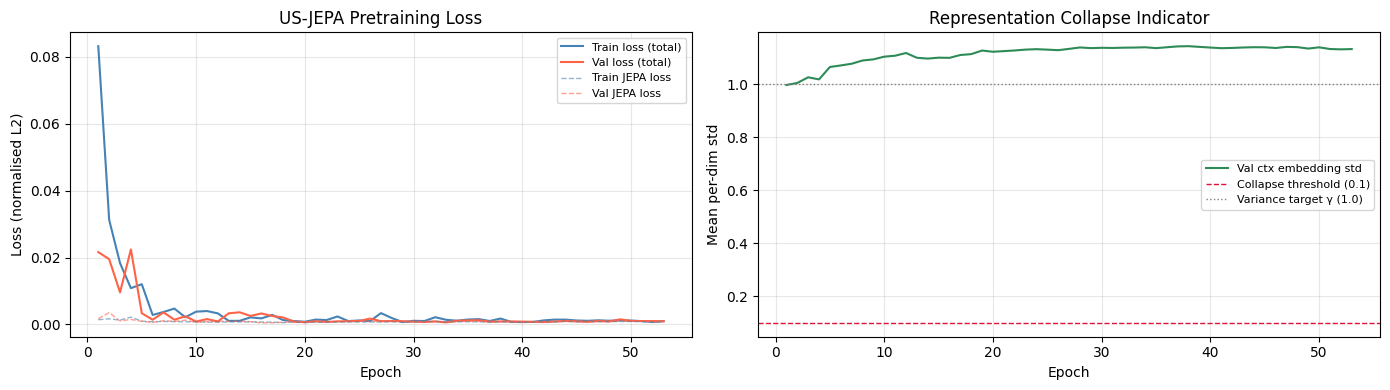

Best val loss: 0.00063


In [ ]:
#Training loss curves + collapse diagnostic
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_x = range(1, len(history['train']) + 1)
ax = axes[0]
ax.plot(epochs_x, history['train'],      label='Train loss (total)', color='steelblue', lw=1.5)
ax.plot(epochs_x, history['val'],        label='Val loss (total)',   color='tomato',    lw=1.5)
ax.plot(epochs_x, history['train_jepa'], label='Train JEPA loss',    color='steelblue', lw=1, ls='--', alpha=0.6)
ax.plot(epochs_x, history['val_jepa'],   label='Val JEPA loss',      color='tomato',    lw=1, ls='--', alpha=0.6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (normalised L2)')
ax.set_title('US-JEPA Pretraining Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax2 = axes[1]
ax2.plot(epochs_x, history['val_ctx_std'], label='Val ctx embedding std', color='seagreen', lw=1.5)
ax2.axhline(CFG['collapse_std_thresh'], color='crimson', lw=1, ls='--',
            label=f'Collapse threshold ({CFG["collapse_std_thresh"]})')
ax2.axhline(CFG['variance_gamma'], color='gray', lw=1, ls=':',
            label=f'Variance target γ ({CFG["variance_gamma"]})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean per-dim std')
ax2.set_title('Representation Collapse Indicator')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG['checkpoint_dir'], 'loss_curves.png'), dpi=150)
plt.show()
print(f'Best val loss: {best_val:.5f}')
if history['val_ctx_std'] and history['val_ctx_std'][-1] < CFG['collapse_std_thresh']:
    print('⚠ Warning: final-epoch context embeddings look collapsed '
          f'(std={history["val_ctx_std"][-1]:.4f} < {CFG["collapse_std_thresh"]}). '
          'Consider training longer, raising variance_loss_weight, or checking the EMA schedule.')

In [ ]:
# Visualise masking on a few samples
def denorm(t):
    """Reverse Normalize(0.5, 0.5) → [0, 1] for display."""
    return (t * 0.5 + 0.5).clamp(0, 1)

In [ ]:
def visualize_masking(image_paths, transform, model_cfg, n=4, seed=0):
    """
    Show, per sample: Original | Detected ROI | Context (visible to encoder) | Target
    (regions to predict) — so it's immediately visible that every mask block lands
    on anatomical tissue rather than black borders / scanner text.
    """
    rng = random.Random(seed)
    indices = rng.sample(range(len(image_paths)), min(n, len(image_paths)))

    n_patches = (model_cfg['img_size'] // model_cfg['patch_size']) ** 2
    grid_size = model_cfg['img_size'] // model_cfg['patch_size']
    patch_px  = model_cfg['patch_size']

    fig, axes = plt.subplots(n, 4, figsize=(16, 3.5 * n))
    if n == 1:
        axes = axes[np.newaxis]

    for row, idx in enumerate(indices):
        img_tensor, roi_patch_mask, name = load_cubs_item(image_paths[idx], transform=transform, cfg=model_cfg)
        img_np = denorm(img_tensor).squeeze().numpy()
        roi_np = roi_patch_mask.numpy()

        tgt_mask, ctx_mask = sample_block_mask(
            n_patches, grid_size,
            model_cfg['n_target_blocks'],
            model_cfg['target_scale'],
            model_cfg['target_aspect'],
            valid_patch_mask=roi_np,
            max_invalid_frac=model_cfg['roi_max_invalid_frac'],
            restrict_context_to_roi=model_cfg['restrict_context_to_roi'],
            min_distance=model_cfg['min_block_distance'],
            max_overlap=model_cfg['max_overlap'],
            max_trials=model_cfg['max_sampling_trials'],
        )

        # ROI overlay: tint everything outside the detected ROI red
        roi_vis = np.stack([img_np, img_np, img_np], axis=-1)
        outside = ~roi_np.reshape(grid_size, grid_size)
        for pid in range(n_patches):
            r, c = divmod(pid, grid_size)
            if outside[r, c]:
                rs, re = r * patch_px, (r + 1) * patch_px
                cs, ce = c * patch_px, (c + 1) * patch_px
                roi_vis[rs:re, cs:ce, 0] = np.clip(roi_vis[rs:re, cs:ce, 0] * 0.5 + 0.5, 0, 1)
                roi_vis[rs:re, cs:ce, 1] *= 0.4
                roi_vis[rs:re, cs:ce, 2] *= 0.4

        ctx_vis = img_np.copy()
        tgt_vis = img_np.copy()
        for pid in range(n_patches):
            r, c = divmod(pid, grid_size)
            rs, re = r * patch_px, (r + 1) * patch_px
            cs, ce = c * patch_px, (c + 1) * patch_px
            if tgt_mask[pid]:
                ctx_vis[rs:re, cs:ce] = 0.15
            if ctx_mask[pid]:
                tgt_vis[rs:re, cs:ce] = 0.15

        axes[row, 0].imshow(img_np,  cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_title(f'Original: {name}', fontsize=8)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(roi_vis)
        axes[row, 1].set_title('Detected ROI (red = excluded)', fontsize=8)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(ctx_vis, cmap='gray', vmin=0, vmax=1)
        axes[row, 2].set_title('Context (visible to encoder)', fontsize=8)
        axes[row, 2].axis('off')

        axes[row, 3].imshow(tgt_vis, cmap='gray', vmin=0, vmax=1)
        axes[row, 3].set_title('Target (regions to predict)', fontsize=8)
        axes[row, 3].axis('off')

    plt.suptitle('US-JEPA ROI-Constrained Block Masking Visualisation', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['checkpoint_dir'], 'masking_vis.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

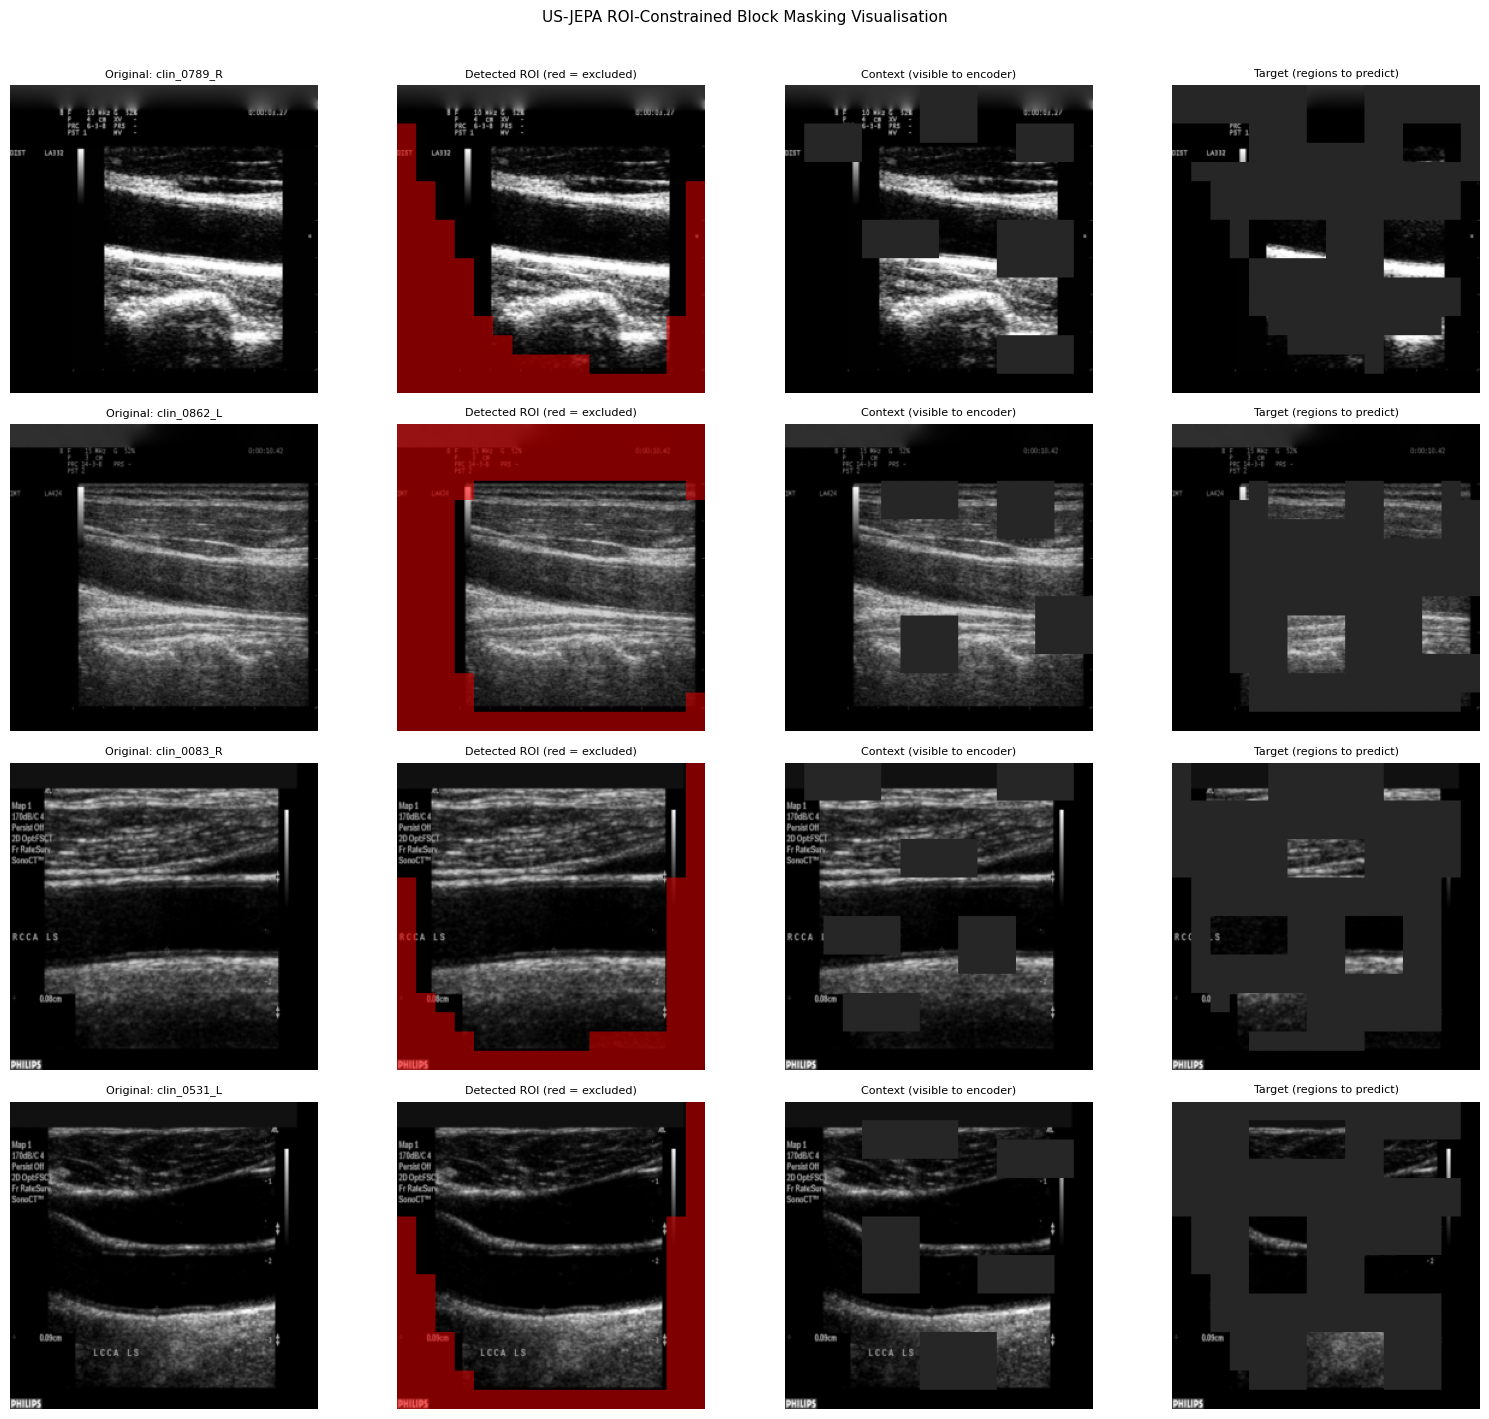

In [ ]:
visualize_masking(all_paths, val_transform, CFG, n=4)

## 9. Saved Outputs Summary

| File | Description |
|------|-------------|
| `checkpoints/config.json` | Full configuration snapshot |
| `checkpoints/best_model.pth` | Full model + optimiser at best val loss |
| `checkpoints/encoder_best.pth` | Context encoder weights (best val) |
| `checkpoints/encoder_final.pth` | Context encoder weights (final epoch) |
| `checkpoints/predictor_final.pth` | Predictor weights (final epoch) |
| `checkpoints/checkpoint_epNNNN.pth` | Periodic checkpoints every N epochs |
| `checkpoints/training_history.json` | Train/val loss per epoch |
| `checkpoints/loss_curves.png` | Loss curve plot |
| `checkpoints/masking_vis.png` | Block masking visualisation |
| `runs/usjepa/` | TensorBoard event files |

In [ ]:
# List all saved files
for f in sorted(glob.glob(os.path.join(CFG['checkpoint_dir'], '*'))):
    size_kb = os.path.getsize(f) / 1024
    print(f'{os.path.basename(f):<45} {size_kb:>8.1f} KB')

best_model.pth                                248300.2 KB
checkpoint_ep0010.pth                         248303.7 KB
checkpoint_ep0020.pth                         248304.4 KB
checkpoint_ep0030.pth                         248305.0 KB
checkpoint_ep0040.pth                         248305.7 KB
checkpoint_ep0050.pth                         248306.5 KB
config.json                                        1.3 KB
encoder_best.pth                               56261.3 KB
encoder_final.pth                              56261.4 KB
loss_curves.png                                    4.3 KB
masking_vis.png                                  777.8 KB
predictor_final.pth                             7742.3 KB
training_history.json                             10.7 KB
